# Reward Model Debug Notebook

**Prerequisito**: eseguire un training christiano con la nuova pipeline.
Questo notebook carica `reward_model.pt` e `debug_data.pkl` dall'output dir
e produce tutti i grafici diagnostici senza richiedere SUMO o l'environment.

In [145]:
# ── Imports ────────────────────────────────────────────────────────────────
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import torch
import torch.nn as nn

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120


In [146]:
# ── Config: punta al tuo run ──────────────────────────────────────────────
# Cambia questo path con la directory del run che vuoi analizzare
RUN_DIR = Path("../outputs/train/2026-05-04_15-20-01_with_regularization_debug_seg_50")

REWARD_MODEL_PATH = RUN_DIR / "reward_model.pt"
DEBUG_DATA_PATH   = RUN_DIR / "debug_data.pkl"


In [147]:
# ── 1. Reward model — ricostruzione standalone ────────────────────────────
# Replica esatta di SimpleRewardNet: nessun import da sumo-rl-ego necessario.

class _SimpleRewardNet(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden_size: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),        nn.Tanh(),
            nn.Linear(hidden_size, 1, bias=False),
        )

    def forward(self, obs: torch.Tensor, act: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([obs, act], dim=1)).squeeze(-1)


def load_reward_ensemble(path):
    """
    Ricostruisce il RewardEnsemble da checkpoint.
    Ritorna (members: list[_SimpleRewardNet], ckpt: dict).
    """
    ckpt = torch.load(path, map_location="cpu", weights_only=True)
    obs_dim, act_dim, hidden = ckpt["obs_dim"], ckpt["act_dim"], ckpt["hidden_size"]
    n = ckpt["n_members"]
    sd = ckpt["state_dict"]

    members = []
    for i in range(n):
        m = _SimpleRewardNet(obs_dim, act_dim, hidden)
        member_sd = {
            k[len(f"members.{i}."):]: v
            for k, v in sd.items()
            if k.startswith(f"members.{i}.")
        }
        m.load_state_dict(member_sd)
        m.eval()
        members.append(m)

    return members, ckpt


members, ckpt = load_reward_ensemble(REWARD_MODEL_PATH)
print(
    f"Caricato ensemble: {ckpt['n_members']} membri  |  "
    f"obs_dim={ckpt['obs_dim']}  act_dim={ckpt['act_dim']}  hidden={ckpt['hidden_size']}"
)


# Helpers di inferenza standalone
@torch.no_grad()
def predict_mean_std(obs: np.ndarray, acts: np.ndarray):
    """Ritorna (mean, std) su (T,) per ogni timestep."""
    obs_t  = torch.tensor(obs,  dtype=torch.float32)
    acts_t = torch.tensor(acts, dtype=torch.float32)
    preds  = np.stack([m(obs_t, acts_t).numpy() for m in members], axis=0)  # (n, T)
    return preds.mean(axis=0), preds.std(axis=0)


Caricato ensemble: 3 membri  |  obs_dim=16  act_dim=2  hidden=256


In [148]:
# ── 2. Caricamento debug data ──────────────────────────────────────────────
with open(DEBUG_DATA_PATH, "rb") as f:
    data = pickle.load(f)

trajs                = data["trajectories"]
ep_true_returns      = np.array(data["episode_true_returns"])
ep_pred_returns      = np.array(data["episode_pred_returns"])

# Flatten step-level arrays for population-level analyses
all_true  = np.concatenate([t["true_rewards"]      for t in trajs])
all_pred  = np.concatenate([t["pred_rewards_mean"] for t in trajs])
all_std   = np.concatenate([t["pred_rewards_std"]  for t in trajs])
all_err   = all_pred - all_true   # signed error
all_abserr = np.abs(all_err)

ep_gap = ep_pred_returns - ep_true_returns

# Statistiche riassuntive
p_ep, _   = pearsonr(ep_true_returns, ep_pred_returns)
s_ep, _   = spearmanr(ep_true_returns, ep_pred_returns)
p_step, _ = pearsonr(all_true, all_pred)

print(f"\nEpisodi: {len(trajs)} | Step totali: {len(all_true)}")
print(f"True return:  mean={ep_true_returns.mean():.2f}  std={ep_true_returns.std():.2f}")
print(f"Pred return:  mean={ep_pred_returns.mean():.2f}  std={ep_pred_returns.std():.2f}")
print(f"Reward gap:   mean={ep_gap.mean():.2f}  (positivo = RM ottimista)")
print(f"Pearson r  (episode):  {p_ep:.3f}")
print(f"Spearman ρ (episode):  {s_ep:.3f}")
print(f"Pearson r  (step):     {p_step:.3f}")
print(f"Step MAE:              {all_abserr.mean():.4f}")
print(f"Step RMSE:             {np.sqrt((all_err**2).mean()):.4f}")



Episodi: 17 | Step totali: 2146
True return:  mean=32.85  std=17.21
Pred return:  mean=28.13  std=10.55
Reward gap:   mean=-4.72  (positivo = RM ottimista)
Pearson r  (episode):  0.991
Spearman ρ (episode):  0.980
Pearson r  (step):     0.366
Step MAE:              0.0929
Step RMSE:             0.4986


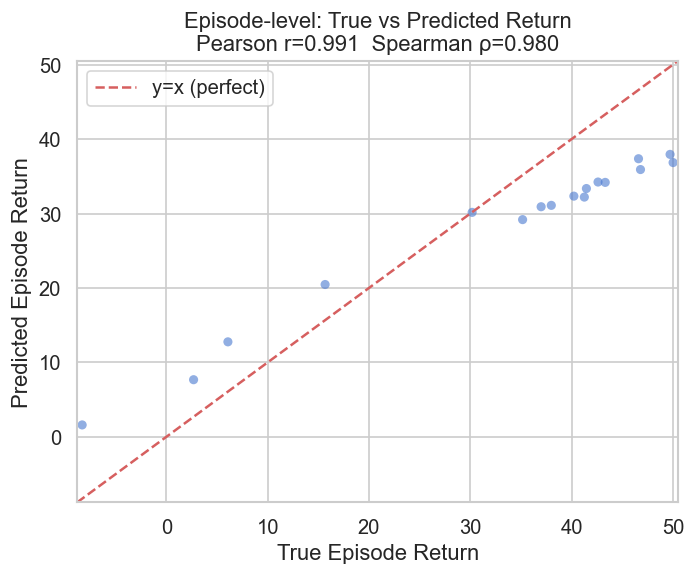

In [149]:
# ── 3. Episode-level scatter: true vs predicted return ────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(ep_true_returns, ep_pred_returns, alpha=0.6, s=30, edgecolors="none")

lim = (min(ep_true_returns.min(), ep_pred_returns.min()) - 0.5,
       max(ep_true_returns.max(), ep_pred_returns.max()) + 0.5)
ax.plot(lim, lim, "r--", lw=1.5, label="y=x (perfect)")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("True Episode Return"); ax.set_ylabel("Predicted Episode Return")
ax.set_title(f"Episode-level: True vs Predicted Return\nPearson r={p_ep:.3f}  Spearman ρ={s_ep:.3f}")
ax.legend()
plt.tight_layout(); plt.savefig(RUN_DIR / "plot_scatter_episode.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Sano   : punti vicini alla diagonale, r > 0.85
# Hacking: cluster in alto a sinistra (pred alta, true bassa) → RM sovrastima
#          su traiettorie che la policy ha imparato a sfruttare


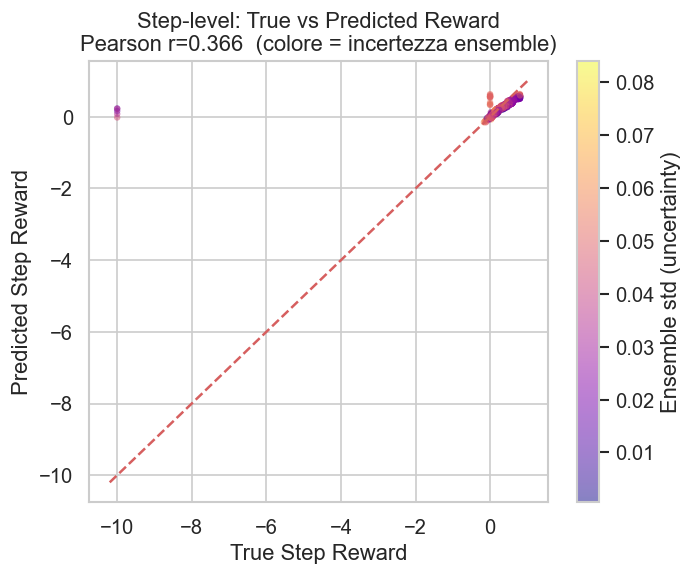

In [150]:
# ── 4. Step-level scatter: true vs predicted reward ───────────────────────
# Campiona max 5000 step per leggibilità
idx = np.random.choice(len(all_true), size=min(5000, len(all_true)), replace=False)

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(all_true[idx], all_pred[idx], c=all_std[idx],
                cmap="plasma", alpha=0.5, s=15, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Ensemble std (uncertainty)")

lim_s = (min(all_true.min(), all_pred.min()) - 0.2,
         max(all_true.max(), all_pred.max()) + 0.2)
ax.plot(lim_s, lim_s, "r--", lw=1.5)
ax.set_xlabel("True Step Reward"); ax.set_ylabel("Predicted Step Reward")
ax.set_title(f"Step-level: True vs Predicted Reward\nPearson r={p_step:.3f}  (colore = incertezza ensemble)")
plt.tight_layout(); plt.savefig(RUN_DIR / "plot_scatter_step.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Colore scuro (alta std) in regioni con errore elevato → uncertainty calibrata
# Colore chiaro (bassa std) con errore elevato → false confidence (danger zone)


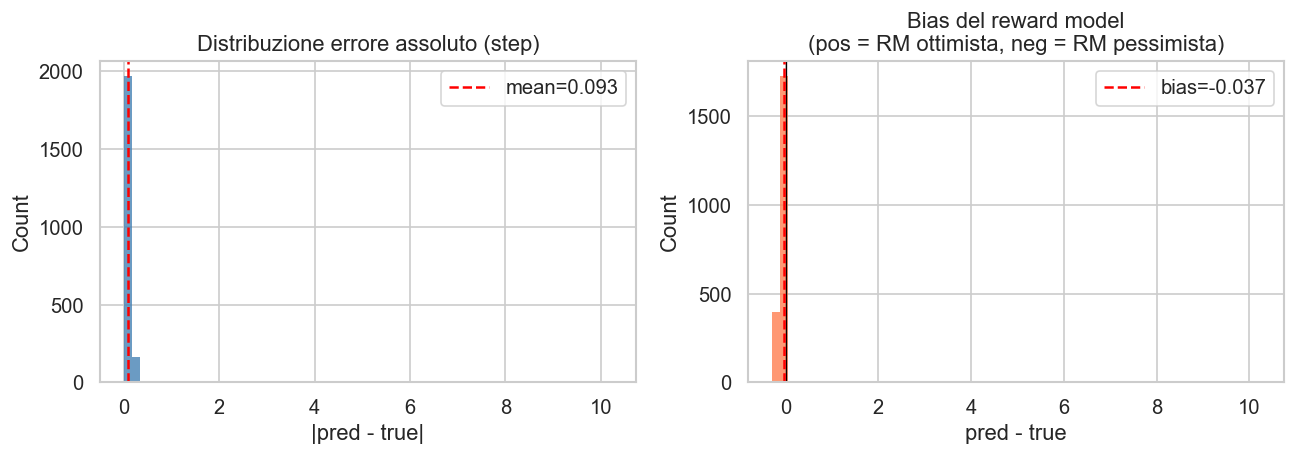

In [151]:
# ── 5. Distribuzione dell'errore step-level ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Istogramma dell'errore assoluto
axes[0].hist(all_abserr, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].axvline(all_abserr.mean(), color="red", ls="--", label=f"mean={all_abserr.mean():.3f}")
axes[0].set_xlabel("|pred - true|"); axes[0].set_ylabel("Count")
axes[0].set_title("Distribuzione errore assoluto (step)"); axes[0].legend()

# Istogramma dell'errore signed (bias del RM)
axes[1].hist(all_err, bins=60, color="coral", edgecolor="none", alpha=0.8)
axes[1].axvline(0, color="black", ls="-", lw=0.8)
axes[1].axvline(all_err.mean(), color="red", ls="--", label=f"bias={all_err.mean():.3f}")
axes[1].set_xlabel("pred - true"); axes[1].set_ylabel("Count")
axes[1].set_title("Bias del reward model\n(pos = RM ottimista, neg = RM pessimista)"); axes[1].legend()

plt.tight_layout(); plt.savefig(RUN_DIR / "plot_error_dist.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Media bias > 0 → il RM sistematicamente sovrastima → condizione necessaria per reward hacking
# Distribuzione asimmetrica con coda destra → outlier in cui il RM è molto ottimista


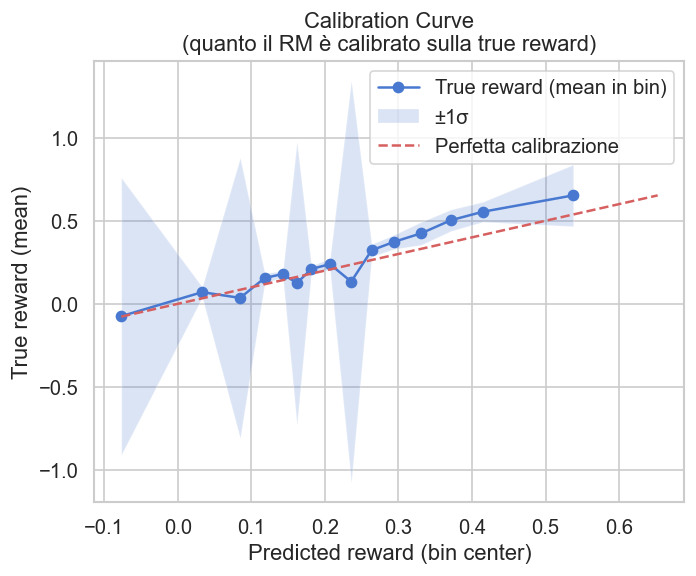

In [152]:
# ── 6. Calibration curve (binned) ─────────────────────────────────────────
N_BINS = 15
bins = np.percentile(all_pred, np.linspace(0, 100, N_BINS + 1))
bin_centers, bin_true_means, bin_true_stds = [], [], []

for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (all_pred >= lo) & (all_pred < hi)
    if mask.sum() < 5:
        continue
    bin_centers.append((lo + hi) / 2)
    bin_true_means.append(all_true[mask].mean())
    bin_true_stds.append(all_true[mask].std())

bin_centers  = np.array(bin_centers)
bin_true_means = np.array(bin_true_means)
bin_true_stds  = np.array(bin_true_stds)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(bin_centers, bin_true_means, "o-", label="True reward (mean in bin)")
ax.fill_between(bin_centers,
                bin_true_means - bin_true_stds,
                bin_true_means + bin_true_stds,
                alpha=0.2, label="±1σ")
diag_min = min(bin_centers.min(), bin_true_means.min())
diag_max = max(bin_centers.max(), bin_true_means.max())
ax.plot([diag_min, diag_max], [diag_min, diag_max], "r--", lw=1.5, label="Perfetta calibrazione")
ax.set_xlabel("Predicted reward (bin center)"); ax.set_ylabel("True reward (mean)")
ax.set_title("Calibration Curve\n(quanto il RM è calibrato sulla true reward)")
ax.legend()
plt.tight_layout(); plt.savefig(RUN_DIR / "plot_calibration.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Curva vicina alla diagonale → RM ben calibrato
# Curva "S" → under-confident al centro, overconfident agli estremi
# Curva piatta → il RM non discrimina tra buone e cattive traiettorie


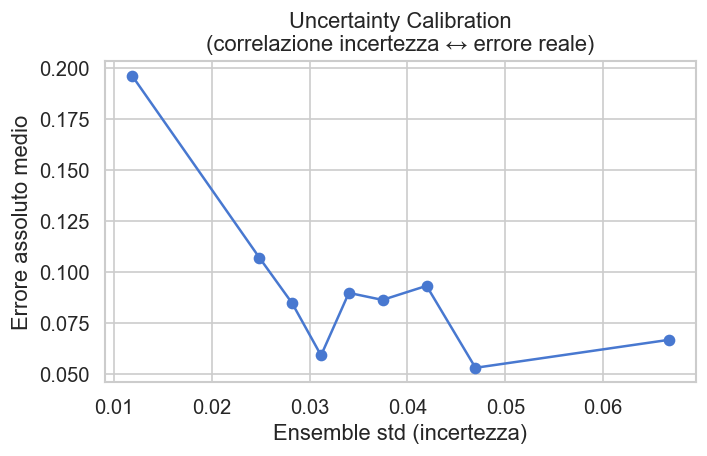

In [153]:
# ── 7. Uncertainty vs errore assoluto ─────────────────────────────────────
# Testa se l'incertezza ensemble è predittiva dell'errore (uncertainty calibration)
fig, ax = plt.subplots(figsize=(6, 4))

std_bins  = np.percentile(all_std, np.linspace(0, 100, 10))
unc_means = [all_abserr[(all_std >= lo) & (all_std < hi)].mean()
             for lo, hi in zip(std_bins[:-1], std_bins[1:])]
unc_ctrs  = [(lo + hi) / 2 for lo, hi in zip(std_bins[:-1], std_bins[1:])]

ax.plot(unc_ctrs, unc_means, "o-")
ax.set_xlabel("Ensemble std (incertezza)"); ax.set_ylabel("Errore assoluto medio")
ax.set_title("Uncertainty Calibration\n(correlazione incertezza ↔ errore reale)")
plt.tight_layout(); plt.savefig(RUN_DIR / "plot_uncertainty_calibration.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Curva crescente → uncertainty predittiva dell'errore → ensemble utile come misura di OOD
# Curva piatta → ensemble non è informativo sull'errore → false confidence generale


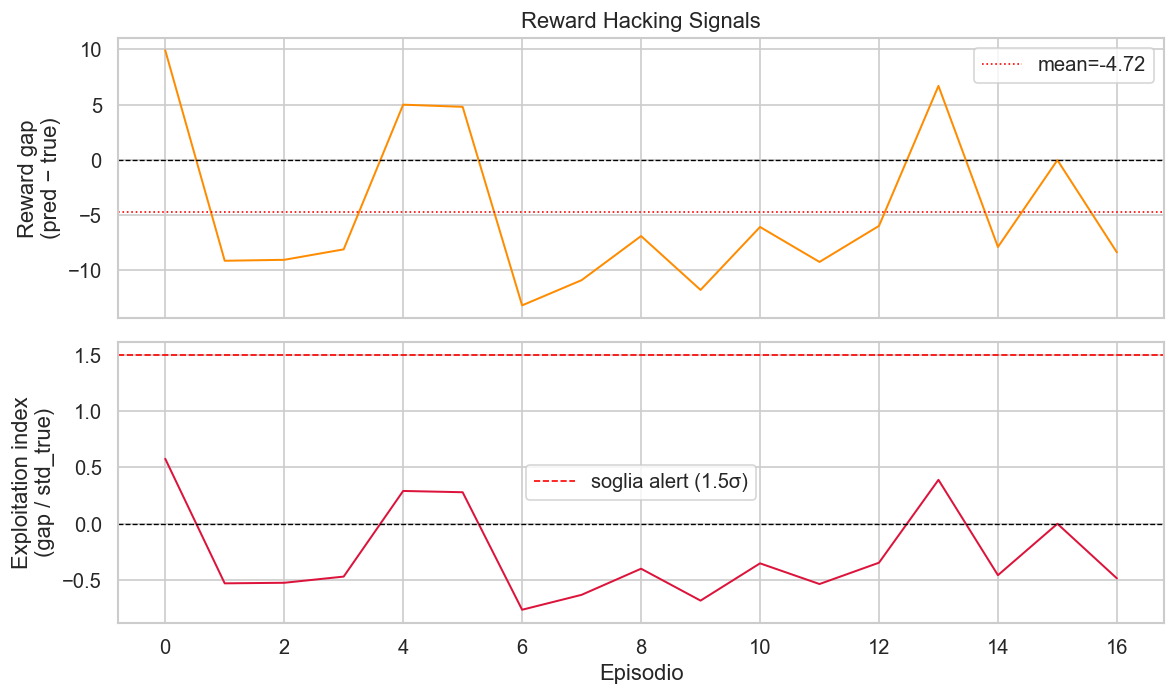

In [154]:
# ── 8. Reward gap over episodes (hacking signal) ──────────────────────────
exploitation_index = ep_gap / (ep_true_returns.std() + 1e-8)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(ep_gap, lw=1.2, color="darkorange")
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].axhline(ep_gap.mean(), color="red", lw=1, ls=":", label=f"mean={ep_gap.mean():.2f}")
axes[0].set_ylabel("Reward gap\n(pred − true)"); axes[0].set_title("Reward Hacking Signals"); axes[0].legend()

axes[1].plot(exploitation_index, lw=1.2, color="crimson")
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].axhline(1.5, color="red", lw=1, ls="--", label="soglia alert (1.5σ)")
axes[1].set_xlabel("Episodio"); axes[1].set_ylabel("Exploitation index\n(gap / std_true)")
axes[1].legend()

plt.tight_layout(); plt.savefig(RUN_DIR / "plot_hacking.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Gap sistematicamente > 0 → il RM sovrastima → condizione per reward hacking
# Exploitation index > 1.5 → segnale forte di hacking (gap > 1.5 std del true reward)
# Trend crescente → la policy sta imparando a sfruttare il RM nel tempo


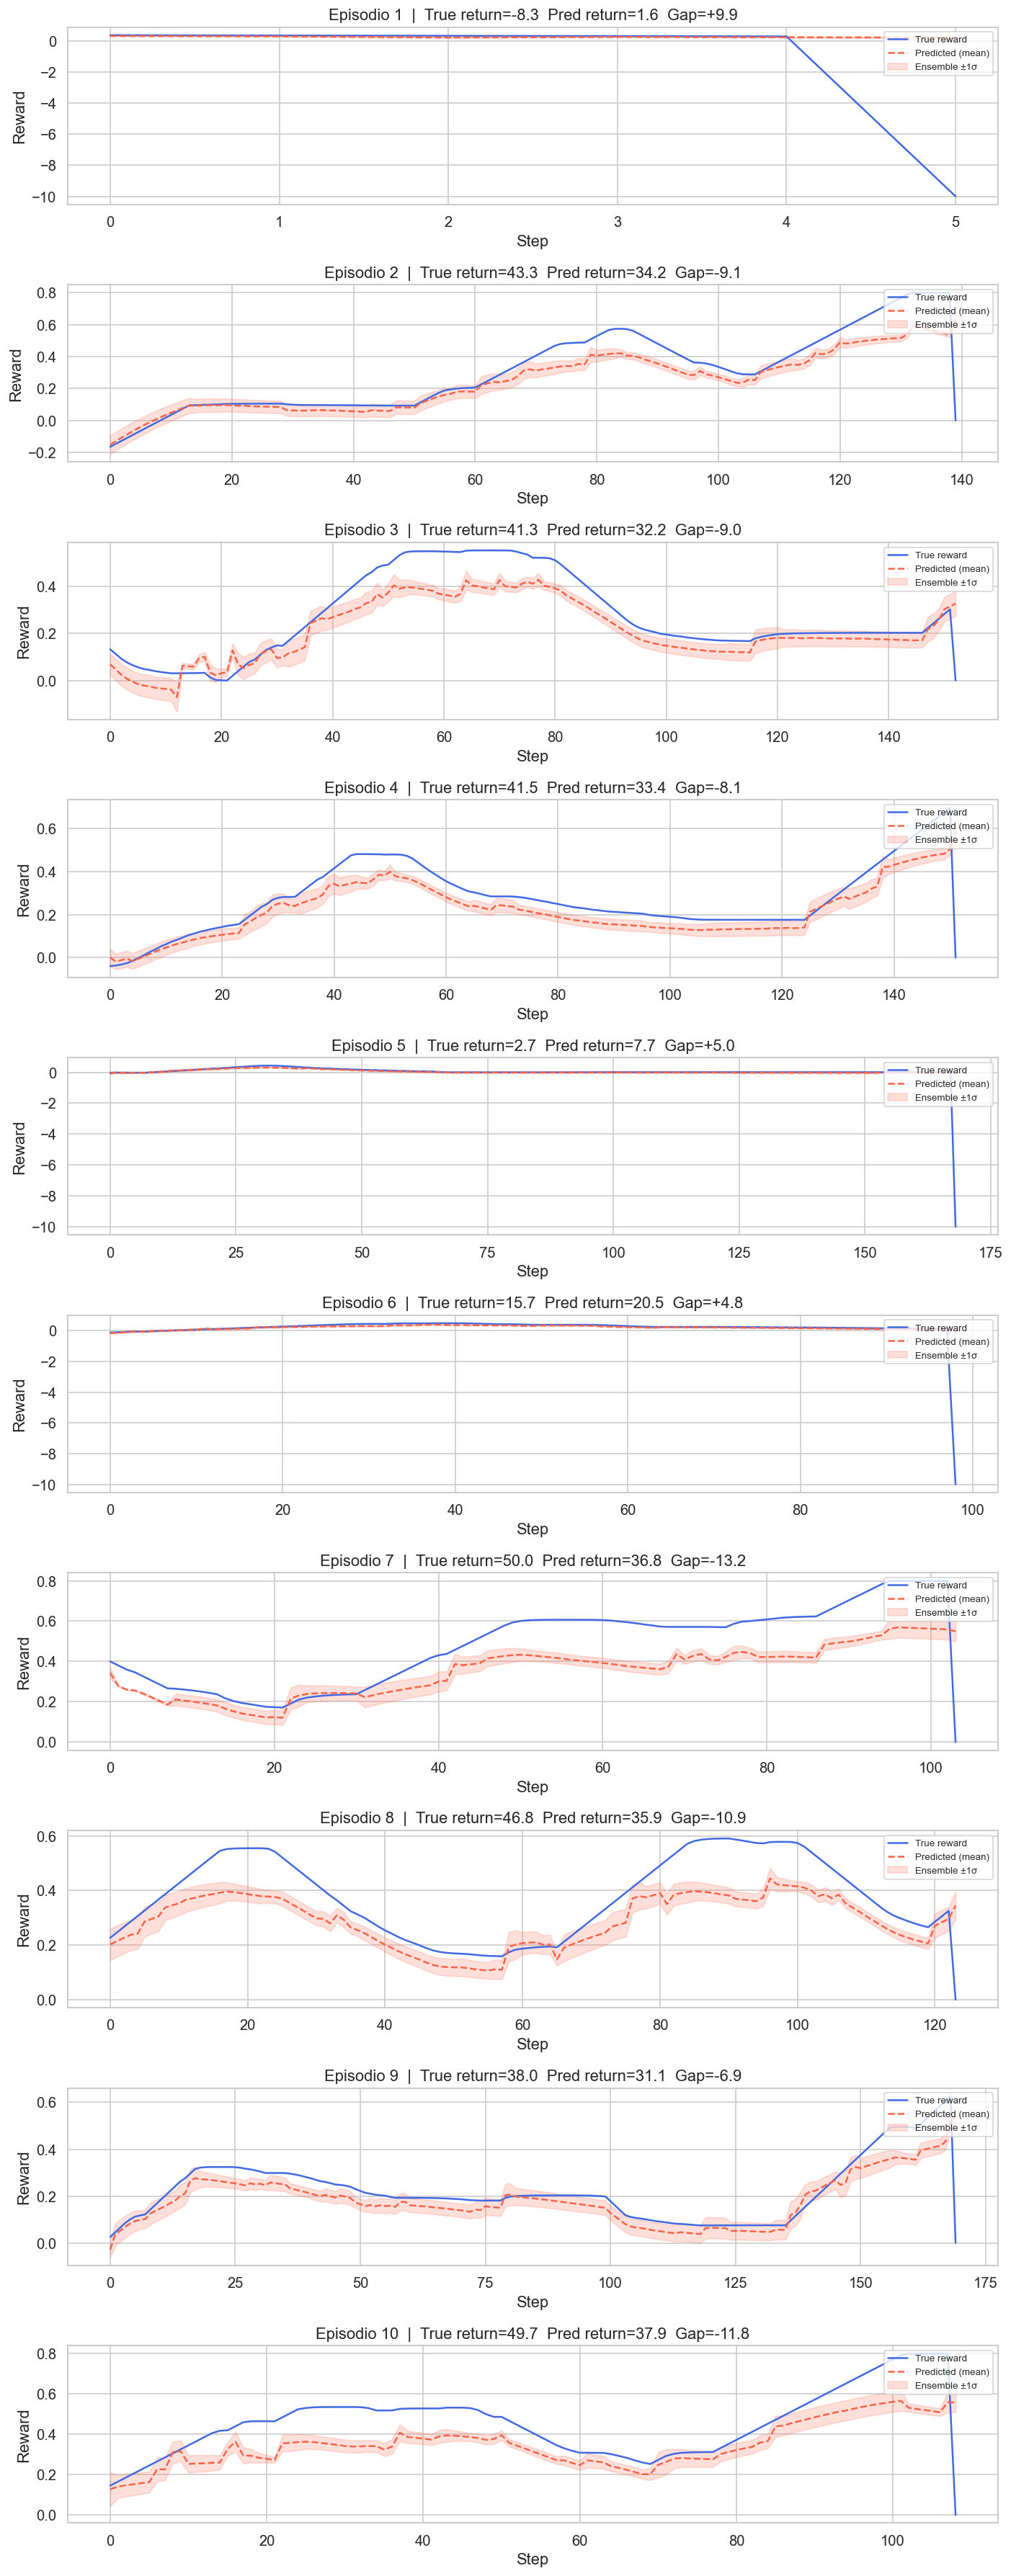

In [158]:
# ── 9. Reward curve per traiettoria (true vs pred) ────────────────────────
# Visualizza le prime 4 traiettorie
N_SHOW = min(10, len(trajs))

fig, axes = plt.subplots(N_SHOW, 1, figsize=(12, 3 * N_SHOW), sharex=False)
if N_SHOW == 1:
    axes = [axes]

for i, (traj, ax) in enumerate(zip(trajs[:N_SHOW], axes)):
    t = np.arange(len(traj["true_rewards"]))
    ax.plot(t, traj["true_rewards"],      label="True reward",      color="royalblue", lw=1.5)
    ax.plot(t, traj["pred_rewards_mean"], label="Predicted (mean)", color="tomato",    lw=1.5, ls="--")
    ax.fill_between(t,
                    traj["pred_rewards_mean"] - traj["pred_rewards_std"],
                    traj["pred_rewards_mean"] + traj["pred_rewards_std"],
                    alpha=0.2, color="tomato", label="Ensemble ±1σ")
    tr  = traj["true_rewards"].sum()
    pr  = traj["pred_rewards_mean"].sum()
    ax.set_title(f"Episodio {i+1}  |  True return={tr:.1f}  Pred return={pr:.1f}  Gap={pr-tr:+.1f}")
    ax.set_xlabel("Step"); ax.set_ylabel("Reward")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.savefig(RUN_DIR / "plot_trajectories.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Curve allineate → RM impara la forma temporale della reward
# RM "liscio" mentre true è rumoroso → RM media bene il segnale
# RM sistematicamente più alto → bias ottimistico → segnale di hacking


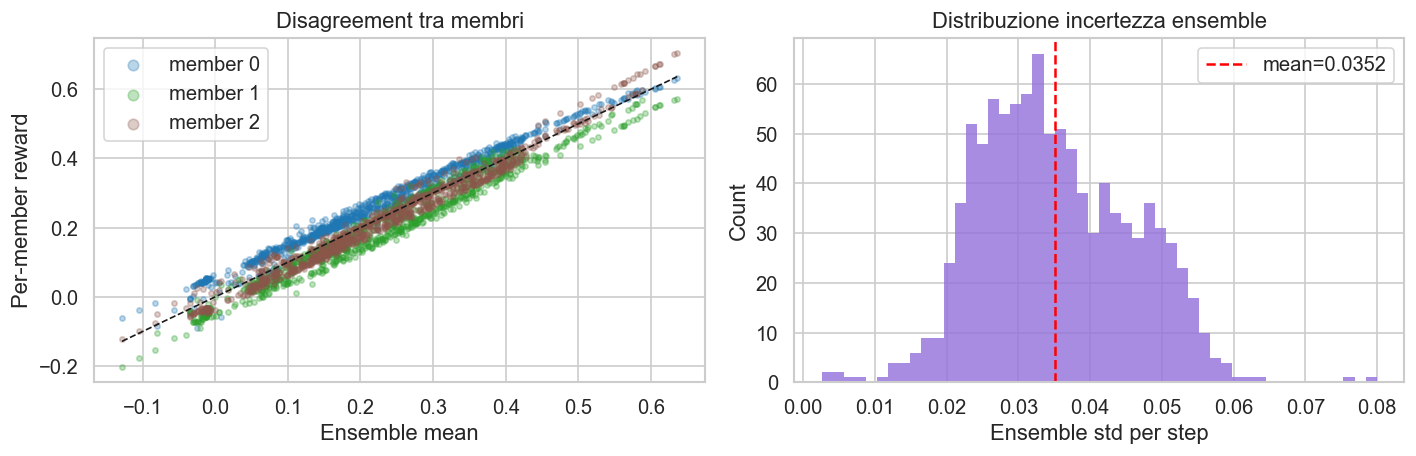

In [156]:
# ── 10. Ensemble member disagreement (step) ───────────────────────────────
# Confronta i singoli membri dell'ensemble su un campione di step
SAMPLE_N = min(1000, len(all_true))
idx_s = np.random.choice(len(all_true), size=SAMPLE_N, replace=False)

# Per ogni campione rigenera le predizioni per-membro
flat_obs  = np.concatenate([t["obs"]     for t in trajs])[idx_s]
flat_acts = np.concatenate([t["actions"] for t in trajs])[idx_s]

with torch.no_grad():
    obs_t  = torch.tensor(flat_obs,  dtype=torch.float32)
    acts_t = torch.tensor(flat_acts, dtype=torch.float32)
    per_member = np.stack([m(obs_t, acts_t).numpy() for m in members], axis=0)  # (n, S)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter di ogni membro contro la media ensemble
member_mean = per_member.mean(axis=0)
colors = plt.cm.tab10(np.linspace(0, 0.5, len(members)))
for i, (row, c) in enumerate(zip(per_member, colors)):
    axes[0].scatter(member_mean, row, s=10, alpha=0.3, color=c, label=f"member {i}")
diag_m = [member_mean.min(), member_mean.max()]
axes[0].plot(diag_m, diag_m, "k--", lw=1)
axes[0].set_xlabel("Ensemble mean"); axes[0].set_ylabel("Per-member reward")
axes[0].set_title("Disagreement tra membri"); axes[0].legend(markerscale=2)

# Istogramma dello std per step
step_stds = per_member.std(axis=0)
axes[1].hist(step_stds, bins=50, color="mediumpurple", edgecolor="none", alpha=0.8)
axes[1].axvline(step_stds.mean(), color="red", ls="--", label=f"mean={step_stds.mean():.4f}")
axes[1].set_xlabel("Ensemble std per step"); axes[1].set_ylabel("Count")
axes[1].set_title("Distribuzione incertezza ensemble"); axes[1].legend()

plt.tight_layout(); plt.savefig(RUN_DIR / "plot_ensemble.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Membri molto allineati → ensemble poco diversificato → incertezza sottostimata
# Std concentrata vicino a 0 → la maggior parte degli stati è in-distribution
# Coda lunga degli std → stati OOD che il RM gestisce con alta varianza


In [157]:
# ── 11. Summary table ──────────────────────────────────────────────────────
print("\n" + "="*55)
print("  REWARD MODEL DIAGNOSTIC SUMMARY")
print("="*55)
print(f"  Run dir:            {RUN_DIR.name}")
print(f"  Ensemble members:   {ckpt['n_members']}")
print(f"  Episodes analyzed:  {len(trajs)}")
print(f"  Steps analyzed:     {len(all_true)}")
print("-"*55)
print(f"  Step-level MAE:         {all_abserr.mean():.4f}")
print(f"  Step-level RMSE:        {np.sqrt((all_err**2).mean()):.4f}")
print(f"  Step-level bias:        {all_err.mean():+.4f}  ({'RM ottimista' if all_err.mean()>0 else 'RM pessimista'})")
print(f"  Step-level Pearson r:   {p_step:.3f}")
print(f"  Episode Pearson r:      {p_ep:.3f}")
print(f"  Episode Spearman ρ:     {s_ep:.3f}")
print(f"  Reward gap (mean):      {ep_gap.mean():+.2f}")
print(f"  Exploitation index:     {exploitation_index.mean():.3f}  ({'⚠ ALTO' if exploitation_index.mean()>1.5 else 'OK'})")
print(f"  Mean ensemble std:      {all_std.mean():.4f}")
print("="*55)

# ── Interpretazione finale ───────────────────────────────────────────────────
# Step Pearson > 0.85  → RM apprende bene a livello di singolo step
# Episode Pearson > 0.85 → RM apprende bene a livello di episodio
# Bias > 0             → RM ottimista → potenziale reward hacking
# Exploitation index > 1.5 → segnale forte di reward hacking



  REWARD MODEL DIAGNOSTIC SUMMARY
  Run dir:            2026-05-04_15-20-01_with_regularization_debug_seg_50
  Ensemble members:   3
  Episodes analyzed:  17
  Steps analyzed:     2146
-------------------------------------------------------
  Step-level MAE:         0.0929
  Step-level RMSE:        0.4986
  Step-level bias:        -0.0374  (RM pessimista)
  Step-level Pearson r:   0.366
  Episode Pearson r:      0.991
  Episode Spearman ρ:     0.980
  Reward gap (mean):      -4.72
  Exploitation index:     -0.274  (OK)
  Mean ensemble std:      0.0353
